### Hann Window

This demo shows the effect of convolving a signal with the raised cosine (Hann)
window. The signal duration is set equal to the window length to clearly
demonstrate the tapering effect. For longer signals, the commented-out for loop
implements Overlap-Add (OLA) synthesis, sliding the window across the signal in
hops of n0/4 (75% overlap).

window length: 512 samples
hop size: 128 samples


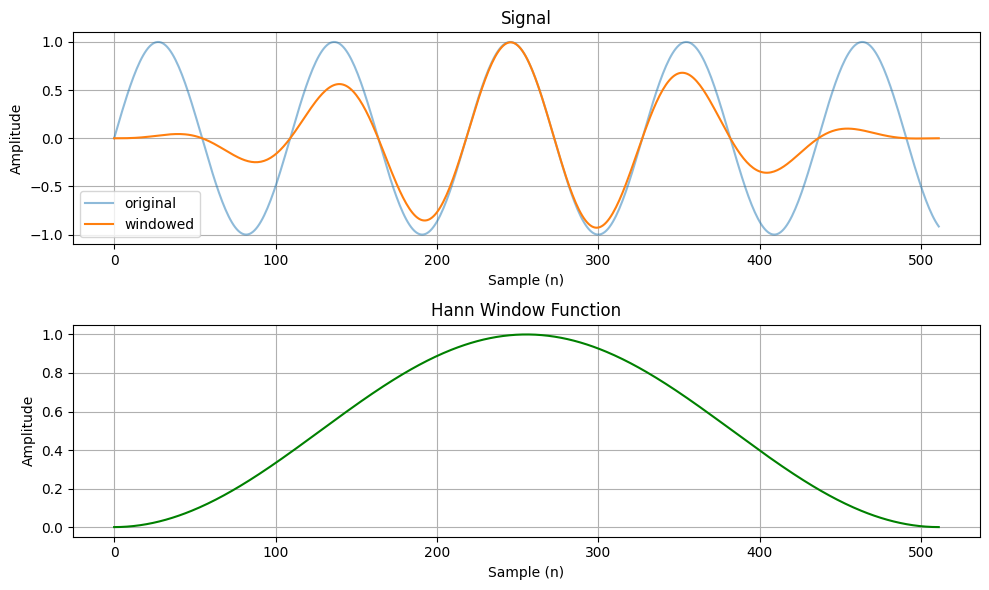

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Signal parameters
Fs = 48e3
f = 440
n0 = 512
hop = n0 // 4

# Signal (exactly one window length)
t = np.arange(n0) / Fs
x = np.sin(2 * np.pi * f * t)


print("window length:", n0, "samples")
print("hop size:", hop, "samples")

# Hann window [Vetterli, p.189]
N = np.arange(n0)
w = 0.5 * (1 - np.cos(2 * np.pi * N / (n0 - 1)))

# Apply window
x_windowed = x * w

### For longer signals, use sliding window instead:

# x_windowed = np.zeros(len(x))
# for i in range(0, len(x) - n0, hop):
#     x_windowed[i:i+n0] += x[i:i+n0] * w

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
n_samples = np.arange(n0)

ax1.plot(n_samples, x, label="original", alpha=0.5)
ax1.plot(n_samples, x_windowed, label="windowed")
ax1.set_xlabel("Sample (n)")
ax1.set_ylabel("Amplitude")
ax1.set_title("Signal")
ax1.legend()
ax1.grid(True)

ax2.plot(N, w, color="green")
ax2.set_xlabel("Sample (n)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Hann Window Function")
ax2.grid(True)

plt.tight_layout()
plt.show()